<div style="text-align:center;">
  <h1 size=10>
    <b>DEEP LEARNING PROJECT</b><br>
    <b>WikiArt Painter Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group XX**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Guilherme Silva (20221910)  
- Maria Carvalho (20221953)
- Maria Miguel Fonseca (20250380)

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Approach Overview](#1)
- [2. Set up & Imports](#2)
- [3. Load Dataset](#3)
- [4. Class Weights](#4)
- [5. Data Preprocessing](#5)
- [6. Modeling](#6)
    - [6.1 Basic Model Comparison](#6_1)
    - [6.2 Optimizer Comparison](#6_2)
    - [6.3 Activation Function Comparison](#6_3)
    - [6.4 Two-Phase Fine Tuning Experiments](#6_4)   
        - [6.4.1 Unfreezing Depth](#6_4_1)
        - [6.4.2 Augmentation Tests](#6_4_2)
        - [6.4.3 Head Architecture Comparison](#6_4_3)
        - [6.4.4 Hyperband Tuning](#6_4_4)
            - [6.4.4.1 EfficientNetV2S](#6_4_4_1)
            - [6.4.4.2 ConvNeXtTiny](#6_4_4_2)
- [7. Final Model](#7)
- [8. Error Analysis](#8)




# <font color='#2f94d7' size=6>**1. Approach Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**2. Set up & Imports**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORT LIBRARIES
import os
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from PIL import Image
import cv2
import pandas as pd

from pathlib import Path
import zipfile


import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from keras.applications import EfficientNetB0, VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shutil
import seaborn as sns

import gc
from keras.applications import VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S

from keras.models import load_model



# Import .py files
import sys
sys.path.append('/content/drive/MyDrive')
from source.functions import *
#from functions import *

In [3]:
# Unzip config
ZIP_PATH   = Path('/content/drive/MyDrive/wikiart_split.zip')  # ajusta se necessário
EXTRACT_TO = Path('/content/wikiart_split')                     # disco local do Colab

if not EXTRACT_TO.exists():
    print('Extracting ZIP... ')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO.parent)
    print('Extraction completed!')
else:
    print('Folder already exists, skipping extraction.')

Folder already exists, skipping extraction.


In [4]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# GENERAL CONFIGURATION
AUTOTUNE    = tf.data.AUTOTUNE
output_dir = "figures"

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')

Keras  : 3.13.2
TF     : 2.19.0
GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# <font color='#2f94d7' size=6>**3. Load Dataset**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [6]:
# DATASET CONFIGURATION
IMG_SIZE    = (512, 512)   # Initial image size (can be adapted later for modeling)
NUM_CLASSES = 23
BATCH_SIZE  = 32

SPLIT_DIR      = Path('wikiart_split')
train_dir_path = SPLIT_DIR / 'train'
val_dir_path   = SPLIT_DIR / 'val'
test_dir_path  = SPLIT_DIR / 'test'

In [7]:
# LOAD DATASETS FROM THE SPLIT FOLDERS
# image_dataset_from_directory infers labels from subfolder names,
# guaranteeing consistent class_names order across machines.

train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir_path,
    label_mode='int', # integer labels for multi-class classification with class weights
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle = True,
    verbose=False,
    seed=SEED
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    val_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False,
    seed=SEED
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False,
    seed=SEED
)

class_names = train_ds_raw.class_names

In [8]:
print(f"Class names: {class_names}")

# Check if labels are correctly inferred (int)
image, label = next(iter(train_ds_raw))
print("Image shape:", image.shape)   # (224, 224, 3)
print("Label:", label.numpy())
print("Class:", class_names[int(label)])

Class names: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']
Image shape: (512, 512, 3)
Label: 0
Class: Albrecht_Durer


# <font color='#2f94d7' size=6>**4. Class Weights**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [9]:
# Compute class weights to handle class imbalance

# Extract labels from training dataset (convert one-hot → class index)
train_labels_flat = np.array([
    y.numpy() for _, y in train_ds_raw
])

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_flat
)

# Convert to dictionary format required by Keras
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

# Display classes with highest weights (rarest classes)
print("Class weights (top 5 heaviest):")
sorted_cw = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)

for idx, w in sorted_cw[:5]:
    print(f"  {class_names[idx]:<10}: {w:.3f}")

Class weights (top 5 heaviest):
  Salvador_Dali: 1.726
  Raphael_Kirchner: 1.599
  Ivan_Shishkin: 1.593
  Ilya_Repin: 1.531
  Childe_Hassam: 1.515


As expected, artists with fewer paintings receive higher class weights. This ensures that misclassifications on these underrepresented classes are penalized more during training, helping to reduce the impact of class imbalance.

# <font color='#2f94d7' size=6>**5. Data Preprocessing**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

In [10]:
# DEFINE AND APPLY DATA AUGMENTATION
base_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),       # ~ ±10°
    layers.RandomTranslation(0.03, 0.03),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
], name="base_augmentation")

train_aug = (train_ds_raw
    .shuffle(10000, seed=SEED)
    .map(lambda x, y: (base_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))
# train_aug is not a dataset that is stored in memory, but a transformation pipeline applied on-the-fly to the training dataset.
# every time train_aug is iterated over, the base_augmentation transformations are applied to the images in train_ds_raw in a randomized manner, creating augmented versions of the images on-the-fly during training.
# loads 1000 samples into a shuffle buffer, shuffles them, and then applies the augmentation transformations to each batch of images as they are fed into the model during training.

In [ ]:
# VISUALISE AUGMENTED TRAINING SAMPLES
sample_imgs, sample_labels = next(iter(train_aug.batch(8)))

print(sample_imgs.dtype)
print(tf.reduce_min(sample_imgs), tf.reduce_max(sample_imgs))

<dtype: 'float32'>
tf.Tensor(1.7893982, shape=(), dtype=float32) tf.Tensor(255.0, shape=(), dtype=float32)


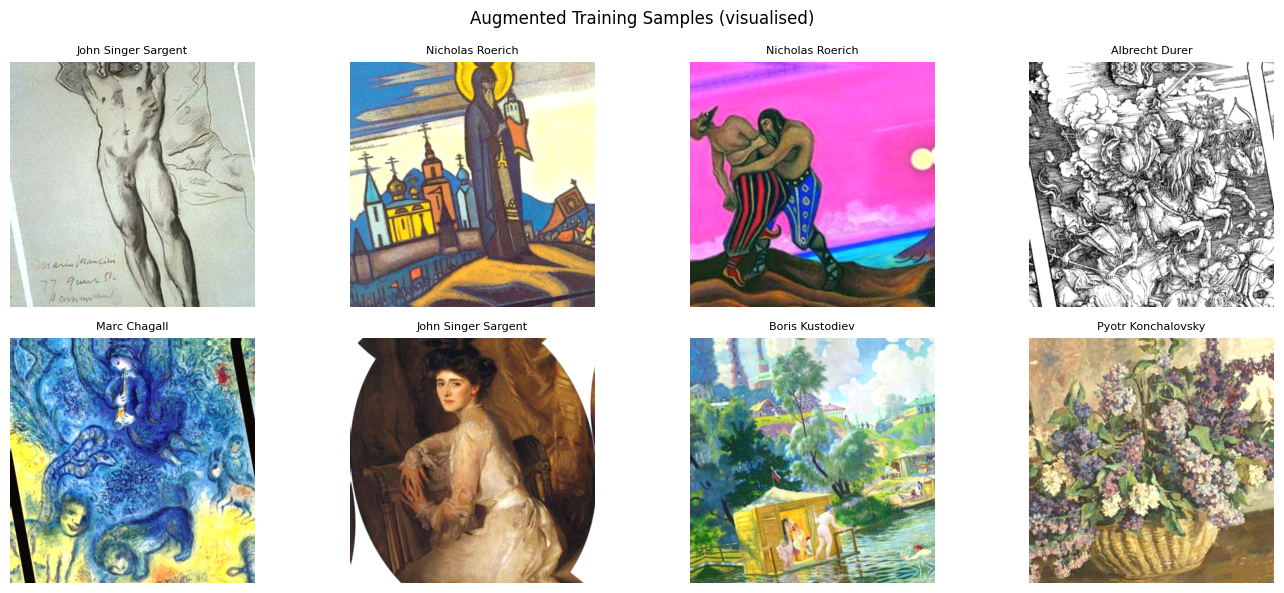

In [ ]:
# imshow expects images in [0, 1] for floats, so we scale down the pixel values for visualization.
sample_display = sample_imgs.numpy() / 255.0

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flatten(), sample_display, sample_labels):
    ax.imshow(img)
    ax.set_title(class_names[int(lbl)].replace('_', ' '), fontsize=8)  # ← int(lbl), não argmax
    ax.axis('off')

plt.suptitle('Augmented Training Samples (visualised)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "augmented_samples.png"), dpi=150)
plt.show()

In [11]:
# RESIZE DATASETS TO DIFFERENT SIZES
# we create separate resized datasets for each image size we want to experiment with during modeling.
train_224, val_224 = build_resized_ds(train_aug, val_ds_raw, 224, AUTOTUNE)
train_300, val_300 = build_resized_ds(train_aug, val_ds_raw, 300, AUTOTUNE)
train_384, val_384 = build_resized_ds(train_aug, val_ds_raw, 384, AUTOTUNE)
train_512 = train_aug
val_512 = val_ds_raw


# <font color='#2f94d7' size=6>**6. Modeling**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

In [12]:
class SparseF1Score(keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # converte inteiros → one-hot antes de passar ao F1Score
        y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        return super().update_state(y_true_onehot, y_pred, sample_weight)

In [13]:
# METRICS - USED IN MODEL EVALUATION AND COMPARISON
def make_metrics():
    return [
        SparseF1Score(average='macro', name='macro_f1'),
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy'),
    ]

## <font color='#2f94d7' size=6>**6.1 Basic Model Comparison**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

To understand how architecture affects performance on artistic style classification, we compare **six backbones** using the same training pipeline (Phase 1 only — frozen backbone, identical head and hyperparameters).

| Backbone | Why include it? |
|---|---|
| **EfficientNetB0** | Our primary model — compound-scaled CNN, strong accuracy/size ratio |
| **VGG16** | Classic deep CNN — large but historically strong on texture/style tasks |
| **ResNet50V2** | Residual connections baseline — widely used reference point |
| **ConvNeXt-Tiny** | Modern pure-CNN (2022) — incorporates Transformer design ideas into a CNN, often outperforms EfficientNets |
| **EfficientNetB3** | More complex version of EfficientNetB0, expects 300x300 sized images|
| **EfficientNetV2S** | Expects 384x384 sized images, is more computanionally heavy, modern and should perform better than the other efficientNet options|


All models use ImageNet pretrained weights. We train only the classification head (frozen backbone) for a fixed number of epochs to ensure a fair comparison. For each backbone the model that will be selected will be the one with the smaller validation loss. Then to compare the backbones we will `val_macro_f1`, `val_top-3-accuracy` and overfit gap.  

We will use the class weights we defined earlier. In this initial phase of testing we will use a simple model (only one Dense intermideate layer) for efficiency and to check which models are more adequate for our data.

In [14]:
# BACKBONE CONFIGS - DEFINES THE BACKBONE MODELS, THEIR PREPROCESSING FUNCTIONS AND THE IMAGE SIZE THEY REQUIRE
BACKBONE_CONFIGS = {
    'EfficientNetB0': {
        'model_fn': EfficientNetB0,
        'preprocess': keras.applications.efficientnet.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
    'EfficientNetB3': {
        'model_fn': EfficientNetB3,
        'preprocess': keras.applications.efficientnet.preprocess_input,
        'image_size': (300, 300),
        'train_ds': train_300,
        'val_ds': val_300
    },
    'EfficientNetV2S': {
        'model_fn': EfficientNetV2S,
        'preprocess': keras.applications.efficientnet_v2.preprocess_input,
        'image_size': (384, 384),
        'train_ds': train_384,
        'val_ds': val_384
    },
    'VGG16': {
        'model_fn': VGG16,
        'preprocess': keras.applications.vgg16.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
    'ResNet50V2': {
        'model_fn': ResNet50V2,
        'preprocess': keras.applications.resnet_v2.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
    'ConvNeXtTiny': {
        'model_fn': ConvNeXtTiny,
        'preprocess': keras.applications.convnext.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
}

In [15]:
# PHASE 1 CONFIGURATION - INITIAL COMPARISON OF BACKBONES WITH FROZEN WEIGHTS AND SIMPLE HEAD
PHASE1_CONFIG = {
  'PHASE1_EPOCHS'    : 20,
  'PHASE1_LR'        : 1e-3,
  'ES_PATIENCE_P1'   : 7,
  'LR_FACTOR_P1'     : 0.3,
  'LR_PATIENCE_P1'   : 4,
  'LR_MIN_P1'        : 1e-6}

In [16]:
# CONFIGURATIONS FOR PHASE 2 - FINE-TUNING THE BEST BACKBONE WITH UNFROZEN WEIGHTS AND OPTIMISED HEAD
PHASE2_CONFIG = {
  'PHASE2_LR'         : 1e-5 ,
  'PHASE2_EPOCHS'     : 30  ,
  'ES_PATIENCE_P2'    : 6,
  'LR_FACTOR_P2'      : 0.3,
  'LR_PATIENCE_P2'    : 3,
  'LR_MIN_P2'         : 1e-7}

In [ ]:
# Comparison loop
comparison_results = {}

for name, cfg in BACKBONE_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'  Training {name}')
    print(f'{"="*60}')

    model, backbone = build_base_model(name, backbone_configs=BACKBONE_CONFIGS, num_classes = NUM_CLASSES)
    train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'], AUTOTUNE = AUTOTUNE, batch_size=BATCH_SIZE)

    # Model parameters
    n_params  = model.count_params()
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f'  Parameters : {n_params:,} total | {trainable:,} trainable')

    # Phase 1 only (frozen backbone)
    hist, _ = run_phase1(model, backbone, train, val, backbone_name=name, phase1_config = PHASE1_CONFIG,
                         phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    # Save results
    metrics = extract_best_metrics(hist, prefix='p1')
    comparison_results[name] = {'params':    n_params, 'trainable': trainable, **metrics}

    r = comparison_results[name]
    print(f'  Overfitting gap (train F1 - val F1): {r["p1_overfit"]:.4f}')
    print(f'  Best val macro F1 : {r["p1_val_f1"]:.4f}')
    print(f'  Best val top-3    : {r["p1_val_top3"]:.4f}')
    print(f'  Min val loss      : {r["p1_val_loss"]:.4f}')

    #  Free memory
    del model, backbone
    keras.backend.clear_session()
    gc.collect()


  Training EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  Parameters : 4,388,538 total | 336,407 trainable
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 364ms/step - loss: 1.8072 - macro_f1: 0.4740 - top3_accuracy: 0.7112 - val_loss: 1.2545 - val_macro_f1: 0.6106 - val_top3_accuracy: 0.8271 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 250ms/step - loss: 1.1221 - macro_f1: 0.6426 - top3_accuracy: 0.8565 - val_loss: 1.1506 - val_macro_f1: 0.6514 - val_top3_accuracy: 0.8551 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 254ms/step - loss: 0.9023 - macro_f1: 0.7032 - top3_accuracy: 0.8931 - val_loss: 1.0770 - val_macro_f1: 0.6772 - val_top3_accuracy: 0.8716 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 251ms/step - loss: 0.7734 - macro_f1: 0.7392 - top3_accuracy: 0.9157 - val_loss: 1.0350 - val_macro_f1: 0.6827 - val_top3_accuracy: 0.8836 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 80

In [ ]:
df_cmp = pd.DataFrame(comparison_results).T.reset_index().rename(columns={
    "index": "Backbone",
    "params": "Total Params",
    "trainable": "Trainable",
    "p1_train_f1": "Train Macro F1",
    "p1_val_f1": "Val Macro F1",
    "p1_val_top3": "Val Top-3",
    "p1_val_loss": "Val Loss",
    "p1_overfit": "F1 Gap"
})

df_cmp["F1 Gap"] = df_cmp["Train Macro F1"] - df_cmp["Val Macro F1"]
df_cmp = df_cmp.sort_values("Val Macro F1", ascending=False).reset_index(drop=True)

Dos gráficos a seguir ver o que faz ou não sentido manter

/tmp/ipykernel_7776/181206695.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")
/tmp/ipykernel_7776/181206695.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")


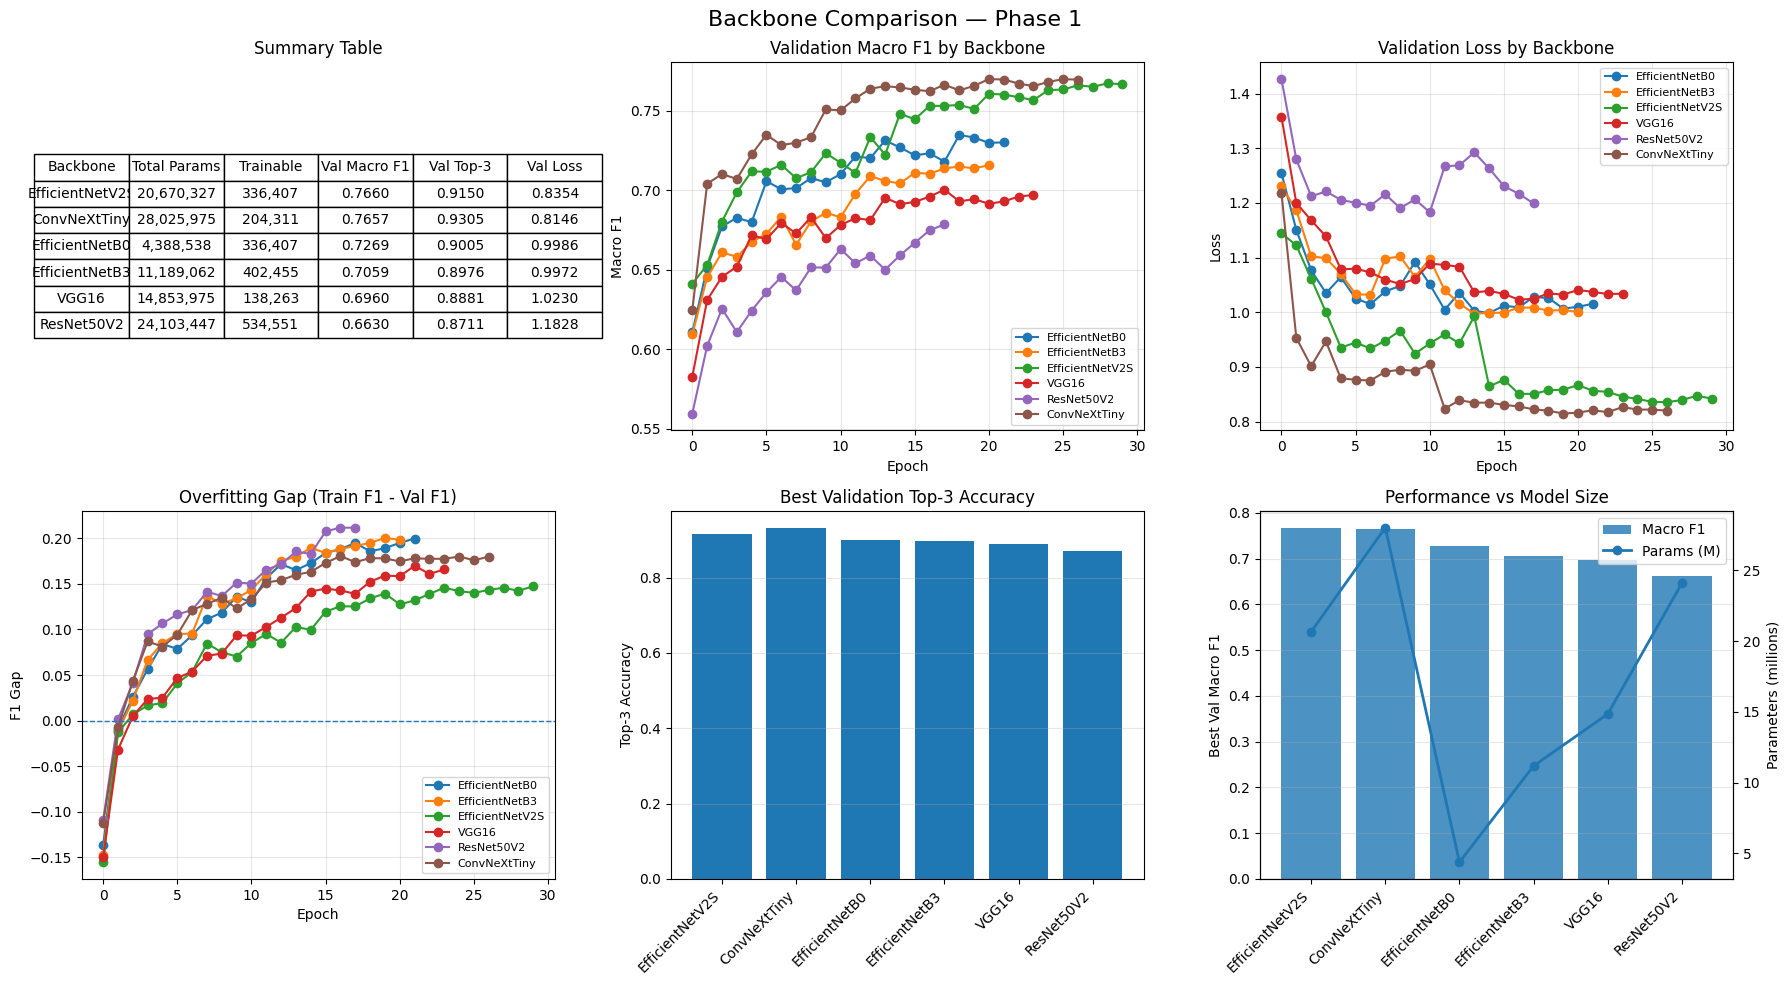

In [ ]:
# Plot comparison dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Backbone Comparison — Phase 1", fontsize=16, y=0.98)

#  Table
axes[0, 0].axis("off")

table_data = df_cmp[["Backbone", "Total Params", "Trainable", "Val Macro F1", "Val Top-3", "Val Loss"]].copy()
table_data["Total Params"] = table_data["Total Params"].map(lambda x: f"{x:,}")
table_data["Trainable"] = table_data["Trainable"].map(lambda x: f"{x:,}")
for col in ["Val Macro F1", "Val Top-3", "Val Loss"]:
    table_data[col] = table_data[col].map(lambda x: f"{x:.4f}")

tbl = axes[0, 0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
axes[0, 0].set_title("Summary Table", fontsize=12)

#  Validation Macro F1 curves
ax = axes[0, 1]
for name, res in comparison_results.items():
    ax.plot(res["p1_history"]["val_macro_f1"], marker="o", label=name)
ax.set_title("Validation Macro F1 by Backbone")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

#  Validation Loss curves
ax = axes[0, 2]
for name, res in comparison_results.items():
    ax.plot(res["p1_history"]["val_loss"], marker="o", label=name)
ax.set_title("Validation Loss by Backbone")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Overfitting gap curves
ax = axes[1, 0]
for name, res in comparison_results.items():
    train_f1 = np.array(res["p1_history"]["macro_f1"])
    val_f1   = np.array(res["p1_history"]["val_macro_f1"])
    gap = train_f1 - val_f1
    ax.plot(gap, marker="o", label=name)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Overfitting Gap (Train F1 - Val F1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1 Gap")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Best Val Top-3 bar chart
ax = axes[1, 1]
ax.bar(df_cmp["Backbone"], df_cmp["Val Top-3"])
ax.set_title("Best Validation Top-3 Accuracy")
ax.set_ylabel("Top-3 Accuracy")
ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)

# Performance vs model size
ax = axes[1, 2]
bars = ax.bar(df_cmp["Backbone"], df_cmp["Val Macro F1"], alpha=0.8, label="Macro F1")
ax.set_ylabel("Best Val Macro F1")
ax.set_title("Performance vs Model Size")
ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)

ax2 = ax.twinx()
ax2.plot(df_cmp["Backbone"], df_cmp["Total Params"] / 1e6, marker="o", linewidth=2, label="Params (M)")
ax2.set_ylabel("Parameters (millions)")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

## <font color='#2f94d7' size=6>**6.2 Optimizer Comparison**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

In [ ]:
# Optimizer Comparison
# Fixed backbone, same head, same resized dataset, same preprocessing, same callbacks.
# Only the optimizer changes.

OPT_BACKBONE = 'EfficientNetV2S'   # change here if you want another backbone
cfg = BACKBONE_CONFIGS[OPT_BACKBONE]

LION_LR = PHASE1_CONFIG['PHASE1_LR'] / 5   # Lion usually benefits from lower LR

OPTIMIZER_CONFIGS = {
    'Adam':    lambda: optimizers.Adam(learning_rate=PHASE1_CONFIG['PHASE1_LR']),
    'AdamW':   lambda: optimizers.AdamW(learning_rate=PHASE1_CONFIG['PHASE1_LR'], weight_decay=1e-4),
    'Lion':    lambda: optimizers.Lion(learning_rate=LION_LR, weight_decay=1e-4),
    'RMSprop': lambda: optimizers.RMSprop(learning_rate=PHASE1_CONFIG['PHASE1_LR'], rho=0.9),
}

In [ ]:
optimizer_results = {}

for opt_name in OPTIMIZER_CONFIGS:
    print(f'\n{"="*60}')
    print(f'  {OPT_BACKBONE} + {opt_name}')
    print(f'{"="*60}')

    model, bb = build_base_model(backbone_name = OPT_BACKBONE, backbone_configs=BACKBONE_CONFIGS, num_classes = NUM_CLASSES)
    train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'],AUTOTUNE = AUTOTUNE, batch_size=BATCH_SIZE)

    # Phase 1 only (frozen backbone)
    hist, _ = run_phase1(model, bb, train, val, backbone_name=f"{OPT_BACKBONE}_{opt_name}", optimizer_fn = OPTIMIZER_CONFIGS[opt_name], phase1_config = PHASE1_CONFIG,
                         phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    # Save results
    optimizer_results[opt_name] = extract_best_metrics(hist, prefix='p1')

    results = optimizer_results[opt_name]
    print(f'  Overfitting gap (train F1 - val F1): {results["p1_overfit"]:.4f}')
    print(f'  Best val macro F1 : {results["p1_val_f1"]:.4f}')
    print(f'  Best val top-3    : {results["p1_val_top3"]:.4f}')
    print(f'  Min val loss      : {results["p1_val_loss"]:.4f}')

    # Free memory
    del model, bb
    keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print(f'  Optimizer comparison complete ({OPT_BACKBONE})')
print(f'{"="*60}')


  EfficientNetV2S + Adam
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 227s 510ms/step - loss: 1.7682 - macro_f1: 0.4896 - top3_accuracy: 0.7296 - val_loss: 1.1837 - val_macro_f1: 0.6294 - val_top3_accuracy: 0.8566 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 307ms/step - loss: 1.1397 - macro_f1: 0.6404 - top3_accuracy: 0.8541 - val_loss: 1.0467 - val_macro_f1: 0.6706 - val_top3_accuracy: 0.8711 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 301ms/step - loss: 0.9789 - macro_f1: 0.6817 - top3_accuracy: 0.8798 - val_loss: 1.0590 - val_macro_f1: 0.6794 - val_top3_accuracy: 0.8756 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 304ms/step - loss: 0.8524 - macro_f1: 0.7184 - top3_accuracy: 0.9057 - val_loss: 1.0854 - val_macro_f1: 0.6811 - val_top3_accuracy: 0.8776 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 308ms/step - loss: 0.8099 - macro_f1: 0.7293 - top

In [ ]:
# Optimizer Comparison Results

print(f'\nOptimizer comparison for backbone: {OPT_BACKBONE}\n')
print(f'{"Optimizer":<20} {"Val Macro F1":>14} {"Val Top-3":>12} {"Val Loss":>10}{"Overfit":>10}')
print('-' * 70)
for name, r in sorted(optimizer_results.items(),
                       key=lambda x: x[1]['p1_val_f1'], reverse=True):
    print(f'{name:<20} {r["p1_val_f1"]:>14.4f} '
          f'{r["p1_val_top3"]:>12.4f} {r["p1_val_loss"]:>10.4f}{r["p1_overfit"]:>10.4f}')


Optimizer comparison for backbone: EfficientNetV2S

Optimizer              Val Macro F1    Val Top-3   Val Loss   Overfit
----------------------------------------------------------------------
Adam                         0.7590       0.9150     0.8595    0.1262
Lion                         0.7517       0.9115     0.9429    0.1344
AdamW                        0.7507       0.9065     0.8287    0.1181
RMSprop                      0.7079       0.8956     0.9495    0.0475


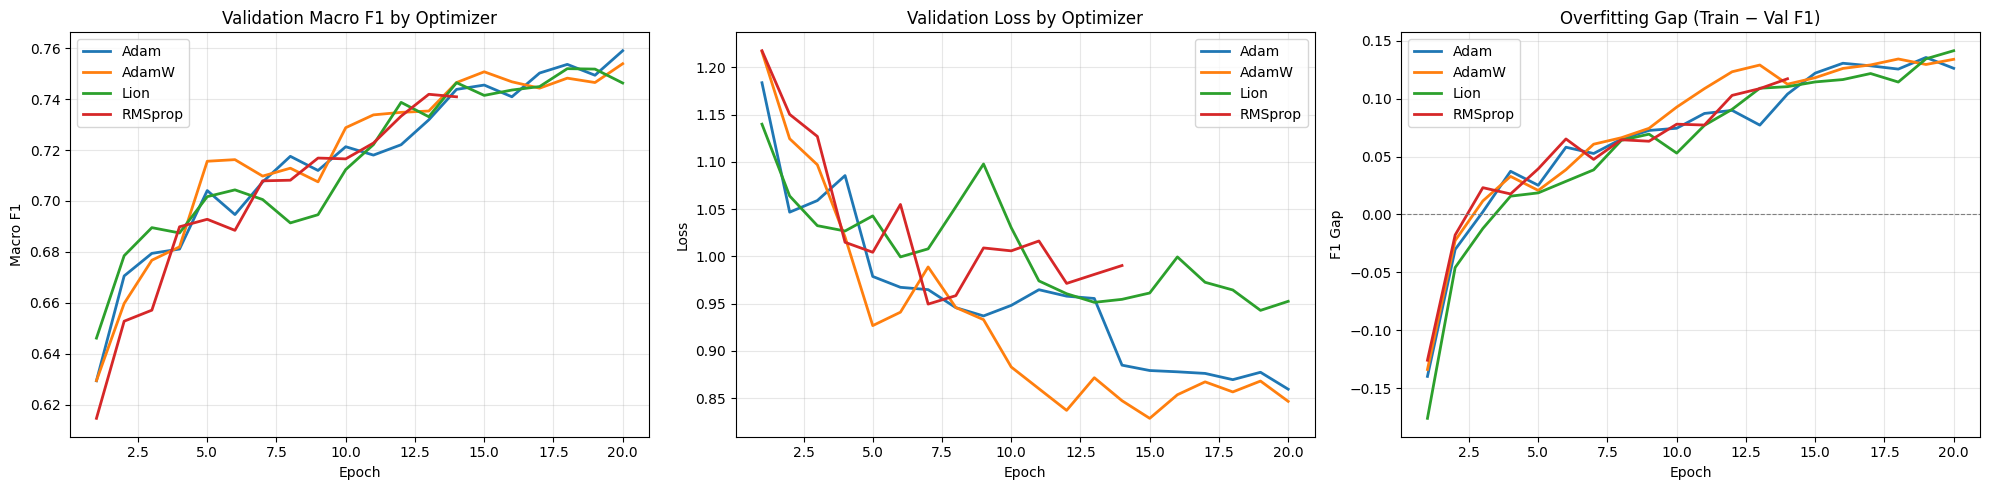

In [ ]:
# Curves: F1, Loss, Overfitting Gap
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name, r in optimizer_results.items():
    hist    = r['p1_history']
    epochs  = range(1, len(hist['val_macro_f1']) + 1)

    axes[0].plot(epochs, hist['val_macro_f1'], label=name, linewidth=2)
    axes[1].plot(epochs, hist['val_loss'],     label=name, linewidth=2)

    gap = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Optimizer')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Optimizer')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The Adam optimizer achieved the best best macro F1 score and Top-3 accurcay, while Adamw showed the smalest validation loss and smaller overfit when compared to Adam. The Lion optimizer almost reaches the performance of Adam in terms of macro F1 score and Top-3 accuracy but has bigger validation loss and overfit. Finally, RMSProp has by far the best overfit value, however, it underperforms when compared to the the other 3 optimizers. From this point onward, we will use the Adam optimizer as a fixed parameter.

## <font color='#2f94d7' size=6>**6.3 Activation Function Comparison**</font> <a class="anchor" id="6_3"></a>

[Back to TOC](#toc)

In [ ]:
ACTIVATIONS = ['relu', 'gelu', 'swish', 'elu', 'leaky_relu']

ACT_BACKBONE = 'EfficientNetV2S'
cfg = BACKBONE_CONFIGS[ACT_BACKBONE]

In [ ]:
activation_results = {}

for act_name in ACTIVATIONS:
    print(f'\n{"="*60}')
    print(f'  {ACT_BACKBONE} + {act_name}')
    print(f'{"="*60}')

    model, bb = build_base_model(backbone_name = ACT_BACKBONE, activation_name = act_name, backbone_configs = BACKBONE_CONFIGS,num_classes = NUM_CLASSES)
    train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'], AUTOTUNE = AUTOTUNE, batch_size=BATCH_SIZE)

    # Phase 1 only (frozen backbone)
    hist, _ = run_phase1(model, bb, train, val, backbone_name=f"{ACT_BACKBONE}_{act_name}", phase1_config = PHASE1_CONFIG,
                         phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    # Save results
    activation_results[act_name] = extract_best_metrics(hist, prefix='p1')

    results = activation_results[act_name]
    print(f'  Overfitting gap (train F1 - val F1): {results["p1_overfit"]:.4f}')
    print(f'  Best val macro F1 : {results["p1_val_f1"]:.4f}')
    print(f'  Best val top-3    : {results["p1_val_top3"]:.4f}')
    print(f'  Min val loss      : {results["p1_val_loss"]:.4f}')

    # Free memory
    del model, bb
    keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print(f'  Activation function comparison complete ({ACT_BACKBONE})')
print(f'{"="*60}')


  EfficientNetV2S + relu
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 471ms/step - loss: 1.7750 - macro_f1: 0.4970 - top3_accuracy: 0.7257 - val_loss: 1.2240 - val_macro_f1: 0.6123 - val_top3_accuracy: 0.8466 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 314ms/step - loss: 1.1652 - macro_f1: 0.6367 - top3_accuracy: 0.8540 - val_loss: 1.0437 - val_macro_f1: 0.6780 - val_top3_accuracy: 0.8766 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 301ms/step - loss: 0.9777 - macro_f1: 0.6877 - top3_accuracy: 0.8902 - val_loss: 1.0949 - val_macro_f1: 0.6707 - val_top3_accuracy: 0.8686 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 308ms/step - loss: 0.8644 - macro_f1: 0.7128 - top3_accuracy: 0.9032 - val_loss: 1.0282 - val_macro_f1: 0.6932 - val_top3_accuracy: 0.8811 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 308ms/step - loss: 0.7975 - macro_f1: 0.7331 - top3_accuracy: 0.9146 - val_loss: 0.9864 - val_macro_

In [ ]:
# Activation Functions Comparison Results

print(f'\nActivation function comparison for backbone: {ACT_BACKBONE}\n')
print(f'{"Activation function":<20} {"Val Macro F1":>14} {"Val Top-3":>12} {"Val Loss":>10}{"Overfit":>10}')
print('-' * 70)

for name, r in sorted(activation_results.items(),
                      key=lambda x: x[1]['p1_val_f1'], reverse=True):
    print(f'{name:<20} {r["p1_val_f1"]:>14.4f} '
          f'{r["p1_val_top3"]:>12.4f} {r["p1_val_loss"]:>10.4f}{r["p1_overfit"]:>10.4f}')


Activation function comparison for backbone: EfficientNetV2S

Activation function    Val Macro F1    Val Top-3   Val Loss   Overfit
----------------------------------------------------------------------
swish                        0.7667       0.9100     0.8441    0.1267
elu                          0.7611       0.9155     0.8272    0.1313
leaky_relu                   0.7508       0.9120     0.8692    0.1331
relu                         0.7418       0.9130     0.8933    0.1378
gelu                         0.7389       0.9020     0.8893    0.0720


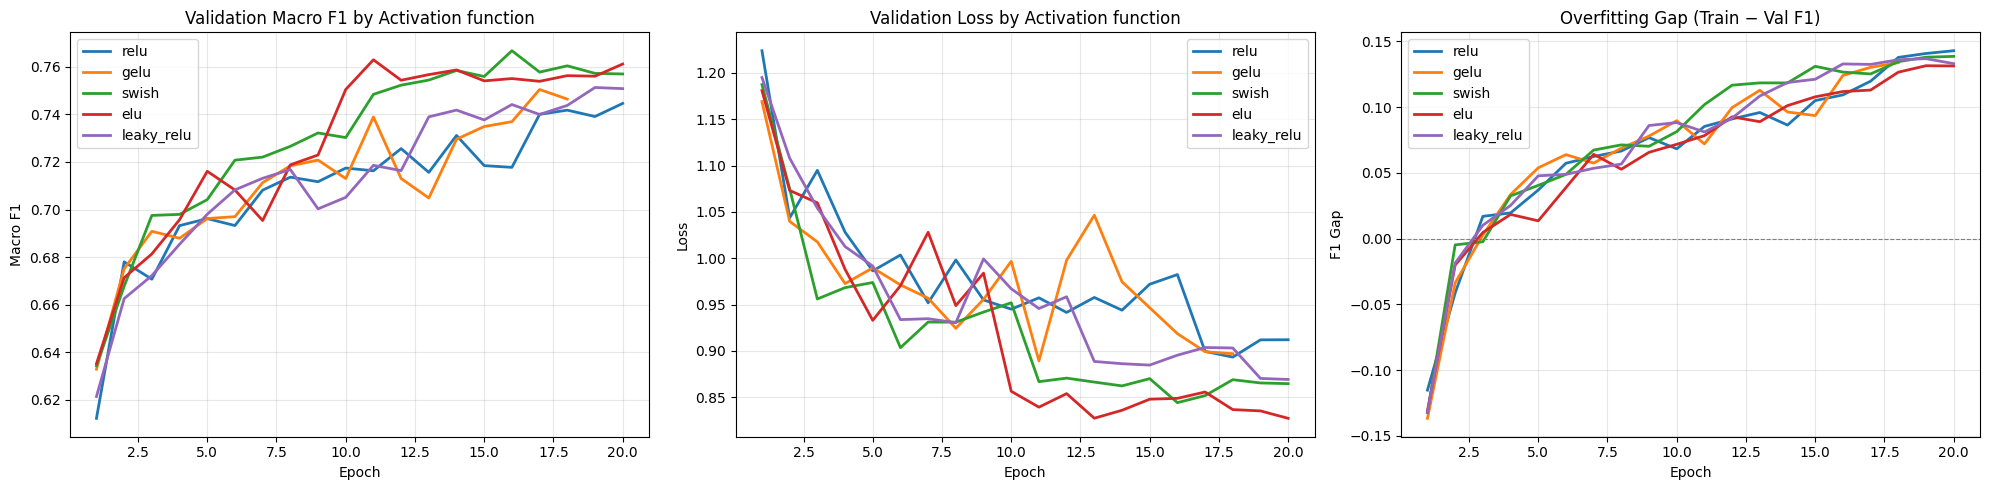

In [ ]:
# Curves: F1, Loss, Overfitting Gap
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name, r in activation_results.items():
    hist    = r['p1_history']
    epochs  = range(1, len(hist['val_macro_f1']) + 1)

    axes[0].plot(epochs, hist['val_macro_f1'], label=name, linewidth=2)
    axes[1].plot(epochs, hist['val_loss'],     label=name, linewidth=2)

    gap = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Activation function')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Activation function')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## <font color='#2f94d7' size=6>**6.4 Two-Phase Fine-Tuning Experiments**</font> <a class="anchor" id="6_4"></a>

[Back to TOC](#toc)

1. **Phase 1 — Feature Extraction**: Freeze the entire model backbone and train only the new classification head. This lets the head adapt without destroying pretrained weights.
2. **Phase 2 — Fine-tuning**: Unfreeze the top portion of the backbone and train end-to-end at a very low learning rate. This adapts higher-level features to the artistic domain.

### <font color='#2f94d7' size=5>**6.4.1 Unfreezing Depth**</font> <a class="anchor" id="6_4_1"></a>

[Back to TOC](#toc)

In this subsection, we evaluate different numbers of layers to unfreeze during the fine-tuning stage. Unfreezing too many layers may excessively alter the pre-trained weights, while unfreezing too few may prevent the model from adequately adapting to the specific characteristics of our dataset.

In [ ]:
UNFREEZE_CANDIDATES = [50, 30, 10, 5] # number of last layers to unfreeze in the backbone for fine-tuning, we will experiment with different values to find the best balance between performance and overfitting risk.
TOP2_BACKBONES = ['ConvNeXtTiny', 'EfficientNetV2S']

In [ ]:
unfreeze_results = {}
backbone_name = TOP2_BACKBONES[0]

print(f'\n{"="*60}\n  {backbone_name}\n{"="*60}')

model, backbone = build_base_model(backbone_name, backbone_configs = BACKBONE_CONFIGS, num_classes = NUM_CLASSES, activation_name='swish')
cfg = BACKBONE_CONFIGS[backbone_name]
train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'], AUTOTUNE=AUTOTUNE, batch_size=BATCH_SIZE)

# Phase 1
hist_p1, phase1_weights = run_phase1(model, backbone, train, val, backbone_name, phase1_config = PHASE1_CONFIG,
                        phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

# Phase 2
for n_unfreeze in UNFREEZE_CANDIDATES:
    exp_name = f"{backbone_name}_unfreeze{n_unfreeze}"
    hist_p2  = run_phase2(model, backbone, train, val, phase1_weights, backbone_name, n_unfreeze, phase1_config = PHASE1_CONFIG, phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    unfreeze_results[exp_name] = {
        'backbone':   backbone_name,
        'n_unfreeze': n_unfreeze,
        **extract_best_metrics(hist_p1, prefix='p1'),
        **extract_best_metrics(hist_p2, prefix='p2'),
    }

    r = unfreeze_results[exp_name]
    print(f'\n  {exp_name}')
    print(f'  Phase 1 → Val F1 : {r["p1_val_f1"]:.4f}')
    print(f'  Phase 2 → Val F1 : {r["p2_val_f1"]:.4f}')
    print(f'  Phase 2 → Top-3  : {r["p2_val_top3"]:.4f}')
    print(f'  Overfitting gap  : {r["p2_overfit"]:.4f}')

del model, backbone
keras.backend.clear_session()
gc.collect()


  ConvNeXtTiny
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 368ms/step - loss: 1.5573 - macro_f1: 0.5326 - top3_accuracy: 0.7579 - val_loss: 1.2000 - val_macro_f1: 0.6277 - val_top3_accuracy: 0.8516 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 257ms/step - loss: 0.8834 - macro_f1: 0.7187 - top3_accuracy: 0.8953 - val_loss: 0.9893 - val_macro_f1: 0.6814 - val_top3_accuracy: 0.8821 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 257ms/step - loss: 0.6959 - macro_f1: 0.7694 - top3_accuracy: 0.9289 - val_loss: 0.9203 - val_macro_f1: 0.7077 - val_top3_accuracy: 0.8911 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 257ms/step - loss: 0.5677 - macro_f1: 0.8053 - top3_accuracy: 0.9439 - val_loss: 0.9083 - val_macro_f1: 0.7205 - val_top3_accuracy: 0.8986 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 254ms/step - loss: 0.5067 - macro_f1: 0.8233 - top3_accura

0

In [ ]:
# Unfreeze Comparison Results
print(f'\nUnfreeze comparison for backbone: {backbone_name}\n')
print(f'{"Experiment":<30} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 75)

# baseline (phase 1 only, backbone frozen)
p1_metrics = extract_best_metrics(hist_p1, prefix='p1')
print(f'{"frozen (phase 1 only)":<30} {p1_metrics["p1_val_f1"]:>10.4f} '
      f'{p1_metrics["p1_val_top3"]:>10.4f} {p1_metrics["p1_val_loss"]:>12.4f} '
      f'{p1_metrics["p1_overfit"]:>10.4f}')

for exp_name, r in sorted(unfreeze_results.items(),
                           key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{exp_name:<30} {r["p2_val_f1"]:>10.4f} '
          f'{r["p2_val_top3"]:>10.4f} {r["p2_val_loss"]:>12.4f} '
          f'{r["p2_overfit"]:>10.4f}')


Unfreeze comparison for backbone: ConvNeXtTiny

Experiment                      P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
---------------------------------------------------------------------------
frozen (phase 1 only)              0.7548     0.9135       0.8635     0.2015
ConvNeXtTiny_unfreeze50            0.7873     0.9310       0.7772     0.2001
ConvNeXtTiny_unfreeze30            0.7777     0.9210       0.8065     0.2057
ConvNeXtTiny_unfreeze10            0.7603     0.9175       0.8540     0.2073
ConvNeXtTiny_unfreeze5             0.7590     0.9150       0.8561     0.2038


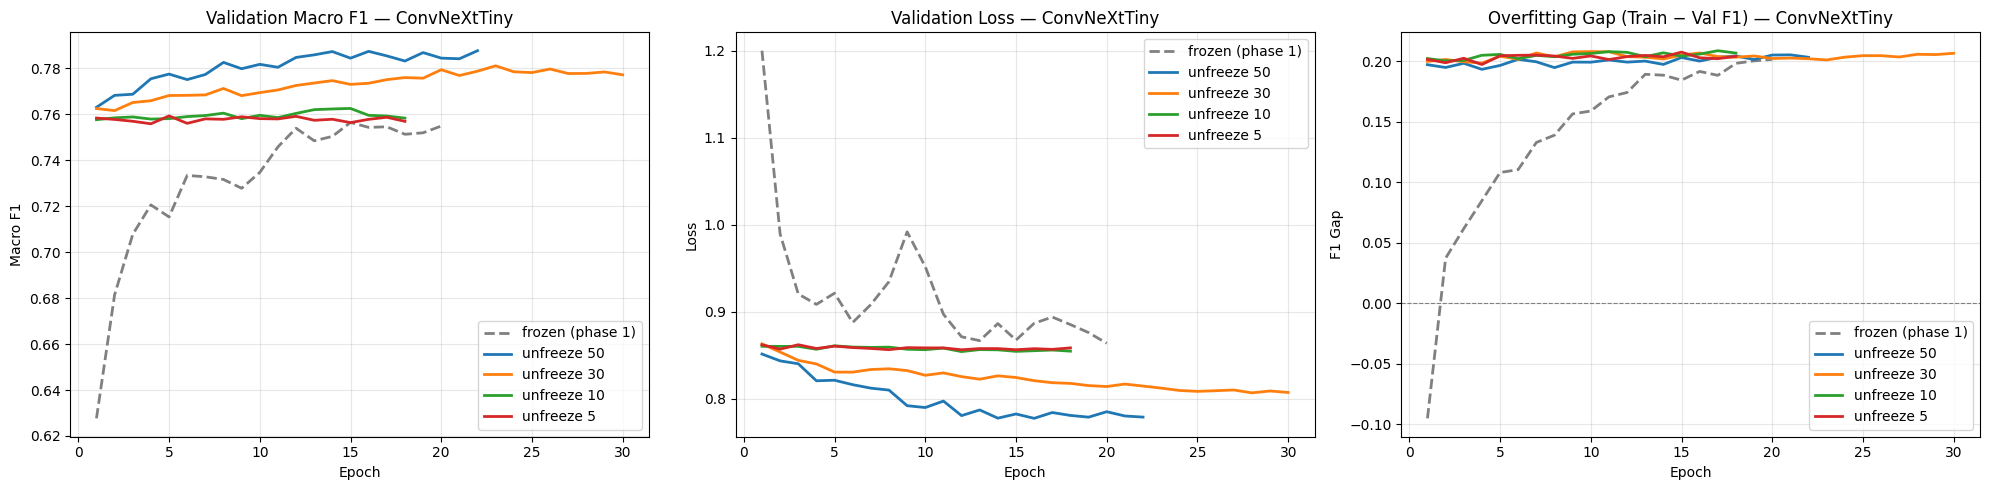

In [ ]:
# Curves: F1, Loss, Overfitting Gap
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Phase 1 only
p1_hist = hist_p1.history
epochs_p1 = range(1, len(p1_hist['val_macro_f1']) + 1)
axes[0].plot(epochs_p1, p1_hist['val_macro_f1'], label='frozen (phase 1)',
             linewidth=2, linestyle='--', color='gray')
axes[1].plot(epochs_p1, p1_hist['val_loss'], label='frozen (phase 1)',
             linewidth=2, linestyle='--', color='gray')
gap_p1 = [tr - va for tr, va in zip(p1_hist['macro_f1'], p1_hist['val_macro_f1'])]
axes[2].plot(epochs_p1, gap_p1, label='frozen (phase 1)',
             linewidth=2, linestyle='--', color='gray')

# Phase 2
for exp_name, r in unfreeze_results.items():
    hist   = r['p2_history']
    label  = f"unfreeze {r['n_unfreeze']}"
    epochs = range(1, len(hist['val_macro_f1']) + 1)

    axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2)
    axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2)
    gap = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=label, linewidth=2)

axes[0].set_title(f'Validation Macro F1 — {backbone_name}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title(f'Validation Loss — {backbone_name}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title(f'Overfitting Gap (Train − Val F1) — {backbone_name}')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
unfreeze_results = {}
backbone_name = TOP2_BACKBONES[1]

print(f'\n{"="*60}\n  {backbone_name}\n{"="*60}')

model, backbone = build_base_model(backbone_name, backbone_configs = BACKBONE_CONFIGS, num_classes = NUM_CLASSES, activation_name='swish')
cfg = BACKBONE_CONFIGS[backbone_name]
train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'], AUTOTUNE=AUTOTUNE, batch_size=BATCH_SIZE)

# Phase 1
hist_p1, phase1_weights = run_phase1(model, backbone, train, val, backbone_name, phase1_config = PHASE1_CONFIG,
                        phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

# Phase 2
for n_unfreeze in UNFREEZE_CANDIDATES:
    exp_name = f"{backbone_name}_unfreeze{n_unfreeze}"
    hist_p2  = run_phase2(model, backbone, train, val, phase1_weights, backbone_name, n_unfreeze, phase1_config = PHASE1_CONFIG, phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    unfreeze_results[exp_name] = {
        'backbone':   backbone_name,
        'n_unfreeze': n_unfreeze,
        **extract_best_metrics(hist_p1, prefix='p1'),
        **extract_best_metrics(hist_p2, prefix='p2'),
    }

    r = unfreeze_results[exp_name]
    print(f'\n  {exp_name}')
    print(f'  Phase 1 → Val F1 : {r["p1_val_f1"]:.4f}')
    print(f'  Phase 2 → Val F1 : {r["p2_val_f1"]:.4f}')
    print(f'  Phase 2 → Top-3  : {r["p2_val_top3"]:.4f}')
    print(f'  Overfitting gap  : {r["p2_overfit"]:.4f}')

del model, backbone
keras.backend.clear_session()
gc.collect()


  EfficientNetV2S
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 217s 491ms/step - loss: 1.6911 - macro_f1: 0.5072 - top3_accuracy: 0.7419 - val_loss: 1.1620 - val_macro_f1: 0.6350 - val_top3_accuracy: 0.8496 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 308ms/step - loss: 1.0976 - macro_f1: 0.6584 - top3_accuracy: 0.8650 - val_loss: 1.0470 - val_macro_f1: 0.6730 - val_top3_accuracy: 0.8761 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 308ms/step - loss: 0.9195 - macro_f1: 0.6996 - top3_accuracy: 0.8977 - val_loss: 1.0162 - val_macro_f1: 0.6942 - val_top3_accuracy: 0.8786 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 302ms/step - loss: 0.8062 - macro_f1: 0.7347 - top3_accuracy: 0.9098 - val_loss: 1.0694 - val_macro_f1: 0.6831 - val_top3_accuracy: 0.8826 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 308ms/step - loss: 0.7499 - macro_f1: 0.7460 - top3_accu

0

In [ ]:
# Unfreeze Comparison Results
print(f'\nUnfreeze comparison for backbone: {backbone_name}\n')
print(f'{"Experiment":<30} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 75)

# baseline (phase 1 only, backbone frozen)
p1_metrics = extract_best_metrics(hist_p1, prefix='p1')
print(f'{"frozen (phase 1 only)":<30} {p1_metrics["p1_val_f1"]:>10.4f} '
      f'{p1_metrics["p1_val_top3"]:>10.4f} {p1_metrics["p1_val_loss"]:>12.4f} '
      f'{p1_metrics["p1_overfit"]:>10.4f}')

for exp_name, r in sorted(unfreeze_results.items(),
                           key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{exp_name:<30} {r["p2_val_f1"]:>10.4f} '
          f'{r["p2_val_top3"]:>10.4f} {r["p2_val_loss"]:>12.4f} '
          f'{r["p2_overfit"]:>10.4f}')


Unfreeze comparison for backbone: EfficientNetV2S

Experiment                      P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
---------------------------------------------------------------------------
frozen (phase 1 only)              0.7503     0.9170       0.8822     0.1533
EfficientNetV2S_unfreeze30         0.7780     0.9255       0.8044     0.1542
EfficientNetV2S_unfreeze50         0.7746     0.9245       0.8246     0.1477
EfficientNetV2S_unfreeze10         0.7686     0.9205       0.8396     0.1605
EfficientNetV2S_unfreeze5          0.7608     0.9170       0.8758     0.1495


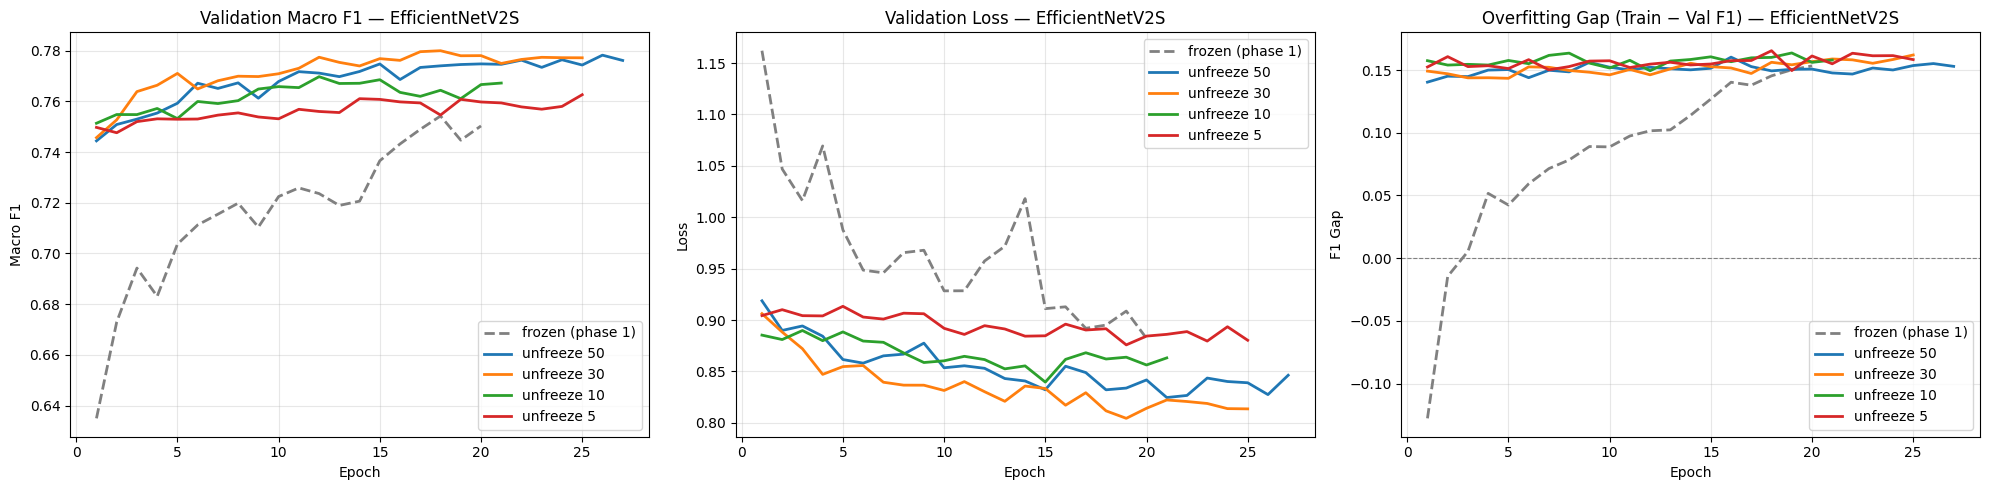

In [ ]:
# Curves: F1, Loss, Overfitting Gap
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Phase 1 only
p1_hist = hist_p1.history
epochs_p1 = range(1, len(p1_hist['val_macro_f1']) + 1)
axes[0].plot(epochs_p1, p1_hist['val_macro_f1'], label='frozen (phase 1)',
             linewidth=2, linestyle='--', color='gray')
axes[1].plot(epochs_p1, p1_hist['val_loss'], label='frozen (phase 1)',
             linewidth=2, linestyle='--', color='gray')
gap_p1 = [tr - va for tr, va in zip(p1_hist['macro_f1'], p1_hist['val_macro_f1'])]
axes[2].plot(epochs_p1, gap_p1, label='frozen (phase 1)',
             linewidth=2, linestyle='--', color='gray')

# Phase 2
for exp_name, r in unfreeze_results.items():
    hist   = r['p2_history']
    label  = f"unfreeze {r['n_unfreeze']}"
    epochs = range(1, len(hist['val_macro_f1']) + 1)

    axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2)
    axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2)
    gap = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=label, linewidth=2)

axes[0].set_title(f'Validation Macro F1 — {backbone_name}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title(f'Validation Loss — {backbone_name}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title(f'Overfitting Gap (Train − Val F1) — {backbone_name}')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### <font color='#2f94d7' size=5>**6.4.2 Augmentation Tests**</font> <a class="anchor" id="6_4_2"></a>

In [17]:
TOP2_BACKBONES = ['EfficientNetV2S', 'ConvNeXtTiny']

UNFREEZE_CONFIG = {
    'EfficientNetV2S': 30,
    'ConvNeXtTiny': 50
}

In [18]:
AUGMENTATION_CONFIGS = {
    # 2. Color heavy — a direção mais promissora dos testes anteriores
    'color_heavy_final': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(0.35),
        layers.RandomContrast(0.35),
        layers.RandomSaturation(factor=(0.5, 1.5)),
        layers.RandomHue(0.08),
    ], name='aug_color_heavy'),

    # 4. Grayscale mix — faz sentido para arte (muitas obras são monocromáticas)
    'grayscale_mix_final': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomGrayscale(factor=0.2),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_grayscale_mix'),
}

In [ ]:
# FULL COMPARISON LOOP
augmentation_results = {}

for backbone_name in TOP2_BACKBONES:
    cfg = BACKBONE_CONFIGS[backbone_name]
    n_unfreeze = UNFREEZE_CONFIG[backbone_name]

    for aug_name, augmentation_model in AUGMENTATION_CONFIGS.items():
        results = run_augmentation_experiment(
            train_raw=train_ds_raw,
            val_raw=val_ds_raw,
            backbone_name=backbone_name,
            cfg=cfg,
            backbone_configs=BACKBONE_CONFIGS,
            aug_name=aug_name,
            augmentation_model=augmentation_model,
            n_unfreeze=n_unfreeze,
            num_classes=NUM_CLASSES,
            AUTOTUNE=AUTOTUNE,
            batch_size=BATCH_SIZE,
            seed=SEED,
            class_weight_dict=class_weight_dict,
            make_metrics=make_metrics,
            phase1_config=PHASE1_CONFIG,
            phase2_config=PHASE2_CONFIG
        )

        augmentation_results[f'{backbone_name}_{aug_name}'] = results

        print(f'Best P2 Val Macro F1 : {results["p2_val_f1"]:.4f}')
        print(f'Best P2 Val Top-3    : {results["p2_val_top3"]:.4f}')
        print(f'Min P2 Val Loss      : {results["p2_val_loss"]:.4f}')
        print(f'P2 Overfit Gap       : {results["p2_overfit"]:.4f}')


Backbone     : EfficientNetV2S
Augmentation : color_heavy_final
Unfreeze     : 30
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 223s 496ms/step - loss: 1.9599 - macro_f1: 0.4407 - top3_accuracy: 0.6849 - val_loss: 1.2725 - val_macro_f1: 0.6046 - val_top3_accuracy: 0.8216 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 301ms/step - loss: 1.3825 - macro_f1: 0.5746 - top3_accuracy: 0.8049 - val_loss: 1.1802 - val_macro_f1: 0.6329 - val_top3_accuracy: 0.8506 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 303ms/step - loss: 1.2082 - macro_f1: 0.6186 - top3_accuracy: 0.8444 - val_loss: 1.0366 - val_macro_f1: 0.6796 - val_top3_accuracy: 0.8741 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 304ms/step - loss: 1.1162 - macro_f1: 0.6424 - top3_accuracy: 0.8600 - val_loss: 1.0240 - val_macro_f1: 0.6672 - val_top3_accuracy: 0.8786 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 296ms/step - loss: 1.0492 - macro_f1: 0.6563

In [ ]:
# RESULTS TABLE
print(f'{"Experiment":<35} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 82)

for name, r in sorted(augmentation_results.items(), key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{name:<35} {r["p2_val_f1"]:>10.4f} {r["p2_val_top3"]:>10.4f} {r["p2_val_loss"]:>12.4f} {r["p2_overfit"]:>10.4f}')

Experiment                           P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
----------------------------------------------------------------------------------
ConvNeXtTiny_grayscale_mix_final        0.8119     0.9430       0.6454     0.1692
ConvNeXtTiny_color_heavy_final          0.7935     0.9345       0.7316     0.1554
EfficientNetV2S_grayscale_mix_final     0.7849     0.9200       0.7766     0.1239
EfficientNetV2S_color_heavy_final       0.7762     0.9200       0.7577     0.0726


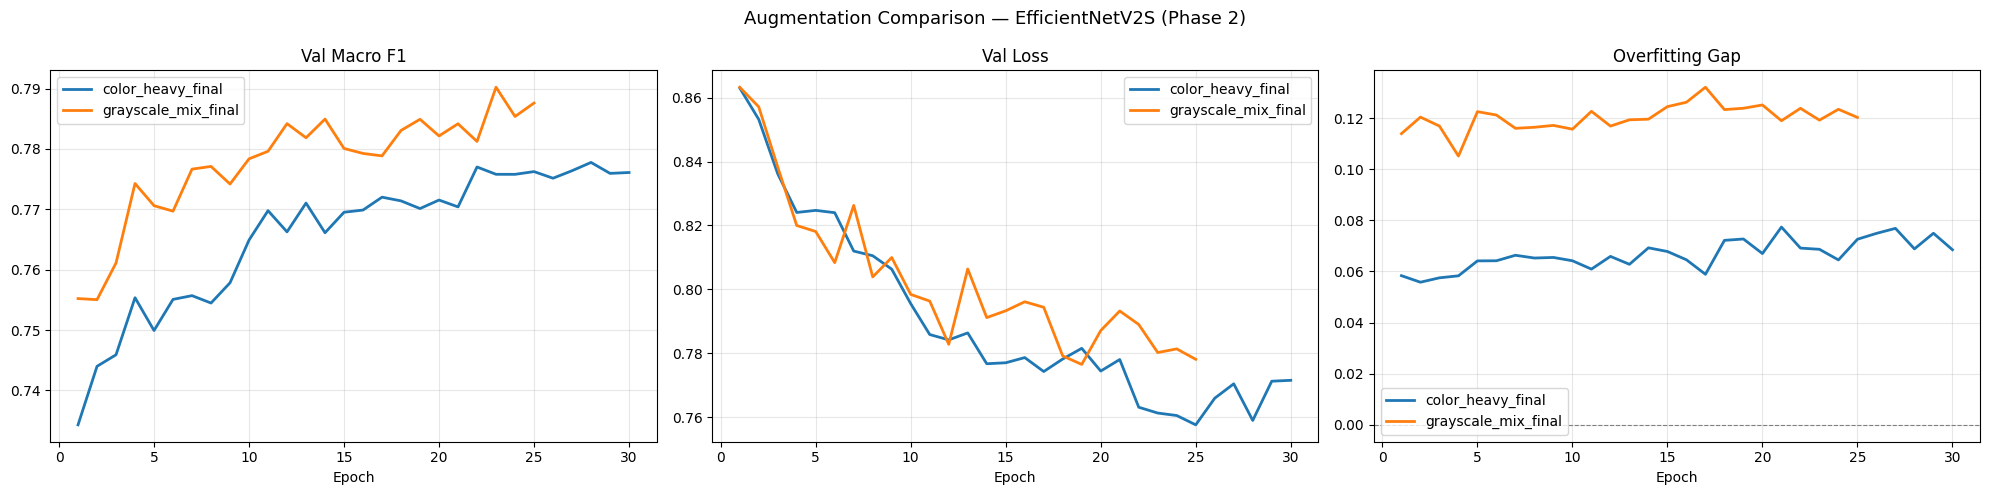

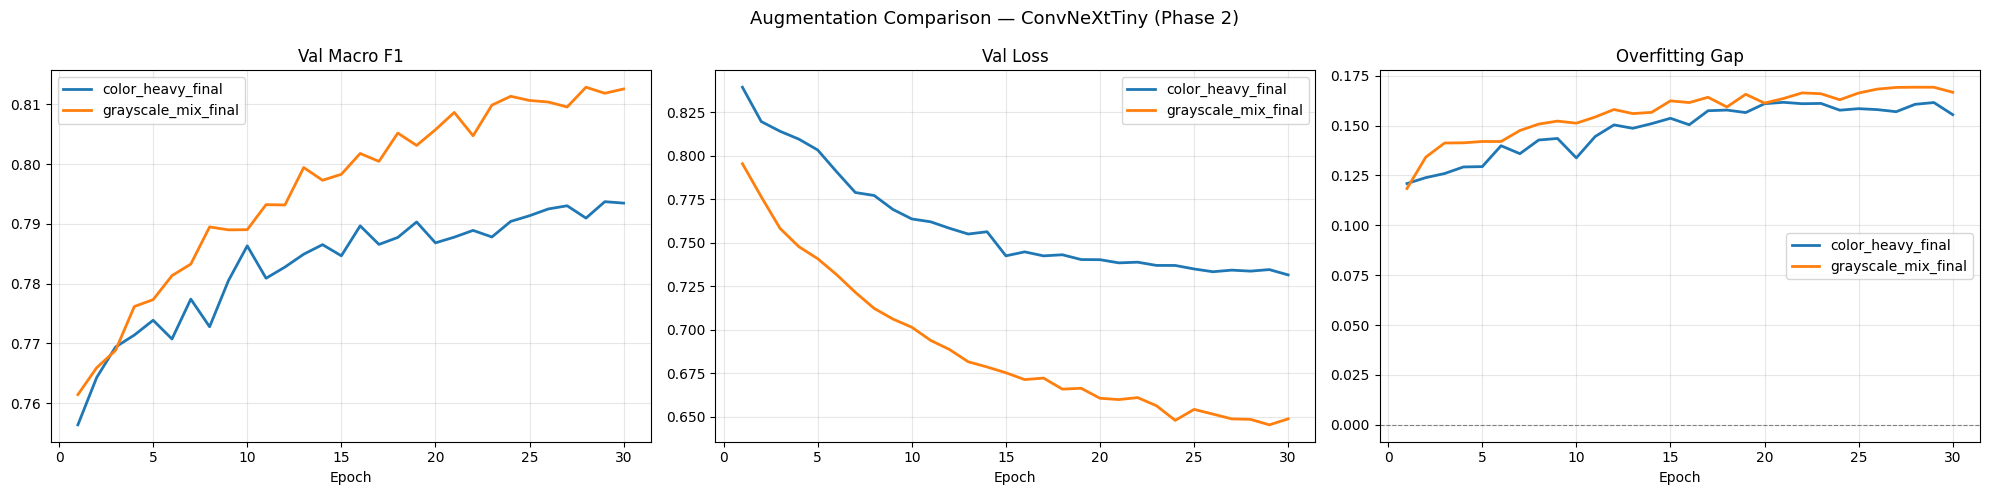

In [ ]:
for backbone_name in TOP2_BACKBONES:
    exps = {k: v for k, v in augmentation_results.items()
            if v['backbone'] == backbone_name}

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Augmentation Comparison — {backbone_name} (Phase 2)', fontsize=13)

    for exp_name, r in exps.items():
        hist  = r['p2_history']
        label = r['augmentation']
        epochs = range(1, len(hist['val_macro_f1']) + 1)
        gap = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]

        axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2)
        axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2)
        axes[2].plot(epochs, gap,                  label=label, linewidth=2)

    for ax, title in zip(axes, ['Val Macro F1', 'Val Loss', 'Overfitting Gap']):
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'aug_comparison_{backbone_name}.png'), dpi=150)
    plt.show()

### <font color='#2f94d7' size=5>**6.4.3 Head Architecture Comparison**</font> <a class="anchor" id="6_4_3"></a>


So far all experiments have used a single Dense(256) layer in the classification head. Here we test whether **deeper heads** can better exploit the features learned by the backbone, particularly after fine-tuning.

We compare three configurations using a simple funnel strategy (each layer halves the neurons of the previous):

| Configuration | Dense layers    | Total head params (approx.) |
|---|---|---|
| `1_layer`  | 256             | baseline                   |
| `2_layers` | 256 → 128       | +33k params                |
| `3_layers` | 256 → 128 → 64  | +41k params                |

**Controlled variables:**
- Backbones: ConvNeXtTiny and EfficientNetV2S (top-2 from Section 6.1)
- Unfreeze depths: 50 for ConvNeXtTiny, 30 for EfficientNetV2S (Section 6.4.1)
- Activation: swish (Section 6.3)
- Optimizer: Adam (Section 6.2)
- Dropout: 0.3 applied after each Dense layer
- BatchNorm: only the initial one (after GAP), none between Dense layers

**Methodological note:** dropout is applied after *every* Dense layer, including the last one before the softmax — this matches the single-layer baseline (which had Dropout before softmax) and extends consistently to deeper heads. We deliberately avoid adding BatchNorm between Dense layers to isolate the effect of head depth alone.


In [19]:
train_384_final, val_384_final = apply_augmented_preprocess_ds(
    train_raw = train_ds_raw, val_raw = val_ds_raw, preprocess_fn = BACKBONE_CONFIGS['EfficientNetV2S']['preprocess'], augmentation_model = AUGMENTATION_CONFIGS['color_heavy_final'], AUTOTUNE = AUTOTUNE, batch_size = BATCH_SIZE, image_size = 384)
train_224_final, val_224_final = apply_augmented_preprocess_ds(
    train_raw = train_ds_raw, val_raw = val_ds_raw, preprocess_fn = BACKBONE_CONFIGS['ConvNeXtTiny']['preprocess'], augmentation_model = AUGMENTATION_CONFIGS['grayscale_mix_final'], AUTOTUNE = AUTOTUNE, batch_size = BATCH_SIZE, image_size = 224)

In [20]:
BACKBONE_CONFIGS['EfficientNetV2S']['train_ds'] = train_384_final
BACKBONE_CONFIGS['EfficientNetV2S']['val_ds'] = val_384_final
BACKBONE_CONFIGS['ConvNeXtTiny']['train_ds'] = train_224_final
BACKBONE_CONFIGS['ConvNeXtTiny']['val_ds'] = val_224_final

In [21]:
# Test increasing head depth with a simple "funnel" strategy (each layer has half the units of the previous one).
# Dropout applied after each Dense at the same rate as baseline.

HEAD_CONFIGS = {
    '1_layer' : {'dense_units': [256],          'dropout_rate': 0.3},
    '2_layers': {'dense_units': [256, 128],     'dropout_rate': 0.3},
    '3_layers': {'dense_units': [256, 128, 64], 'dropout_rate': 0.3},
}

# Fixed decisions from previous ablations
HEAD_ACTIVATION = 'swish'
# Optimizer is Adam by default in run_phase1 / run_phase2 (Section 6.2)

In [ ]:
# ConvNeXtTiny
# Tests head depth (1, 2, 3 Dense layers) on ConvNeXtTiny, Phase 1 + Phase 2.

head_results_convnext = {}
backbone_name = 'ConvNeXtTiny'
n_unfreeze    = UNFREEZE_CONFIG[backbone_name]
cfg           = BACKBONE_CONFIGS[backbone_name]

for head_name, head_cfg in HEAD_CONFIGS.items():
    exp_name = f"{backbone_name}_head_{head_name}"
    print(f'\n{"="*60}\n  {exp_name}  (unfreeze={n_unfreeze})\n{"="*60}')

    model, backbone = build_base_model(
        backbone_name    = backbone_name,
        backbone_configs = BACKBONE_CONFIGS,
        num_classes      = NUM_CLASSES,
        activation_name  = HEAD_ACTIVATION,
        head_config      = head_cfg,
    )

    # Phase 1 — frozen backbone, head warm-up
    hist_p1, phase1_weights = run_phase1(
        model, backbone, cfg['train_ds'], cfg['val_ds'],
        backbone_name     = exp_name,
        phase1_config     = PHASE1_CONFIG,
        phase2_config     = PHASE2_CONFIG,
        make_metrics      = make_metrics,
        class_weight_dict = class_weight_dict,
    )

    # Phase 2 — unfreeze top layers, fine-tune end-to-end
    hist_p2 = run_phase2(
        model, backbone, cfg['train_ds'], cfg['val_ds'],
        phase1_weights    = phase1_weights,
        backbone_name     = exp_name,
        n_unfreeze        = n_unfreeze,
        phase1_config     = PHASE1_CONFIG,
        phase2_config     = PHASE2_CONFIG,
        make_metrics      = make_metrics,
        class_weight_dict = class_weight_dict,
    )

    head_results_convnext[exp_name] = {
        'backbone':    backbone_name,
        'head':        head_name,
        'dense_units': head_cfg['dense_units'],
        **extract_best_metrics(hist_p1, prefix='p1'),
        **extract_best_metrics(hist_p2, prefix='p2'),
    }

    r = head_results_convnext[exp_name]
    print(f'\n  {exp_name}')
    print(f'  Phase 1 → Val F1 : {r["p1_val_f1"]:.4f}')
    print(f'  Phase 2 → Val F1 : {r["p2_val_f1"]:.4f}')
    print(f'  Phase 2 → Top-3  : {r["p2_val_top3"]:.4f}')
    print(f'  Overfitting gap  : {r["p2_overfit"]:.4f}')

    del model, backbone
    keras.backend.clear_session()
    gc.collect()


  ConvNeXtTiny_head_1_layer  (unfreeze=50)
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 330ms/step - loss: 1.6582 - macro_f1: 0.4980 - top3_accuracy: 0.7315 - val_loss: 1.1406 - val_macro_f1: 0.6476 - val_top3_accuracy: 0.8711 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 207ms/step - loss: 0.9793 - macro_f1: 0.6855 - top3_accuracy: 0.8814 - val_loss: 0.9264 - val_macro_f1: 0.7007 - val_top3_accuracy: 0.8886 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 207ms/step - loss: 0.7758 - macro_f1: 0.7467 - top3_accuracy: 0.9157 - val_loss: 0.8651 - val_macro_f1: 0.7254 - val_top3_accuracy: 0.9050 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 204ms/step - loss: 0.6569 - macro_f1: 0.7792 - top3_accuracy: 0.9362 - val_loss: 0.9147 - val_macro_f1: 0.7166 - val_top3_accuracy: 0.8981 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 207ms/step - loss: 0.5923 - ma

In [ ]:
# Results table (ConvNeXtTiny)
print(f'\nHead comparison for backbone: ConvNeXtTiny\n')
print(f'{"Experiment":<40} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 85)

for name, r in sorted(head_results_convnext.items(), key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{name:<40} {r["p2_val_f1"]:>10.4f} {r["p2_val_top3"]:>10.4f} '
          f'{r["p2_val_loss"]:>12.4f} {r["p2_overfit"]:>10.4f}')


Head comparison for backbone: ConvNeXtTiny

Experiment                                P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
-------------------------------------------------------------------------------------
ConvNeXtTiny_head_1_layer                    0.8134     0.9440       0.6459     0.1670
ConvNeXtTiny_head_2_layers                   0.8093     0.9370       0.6961     0.1469
ConvNeXtTiny_head_3_layers                   0.7990     0.9235       0.7151     0.1426


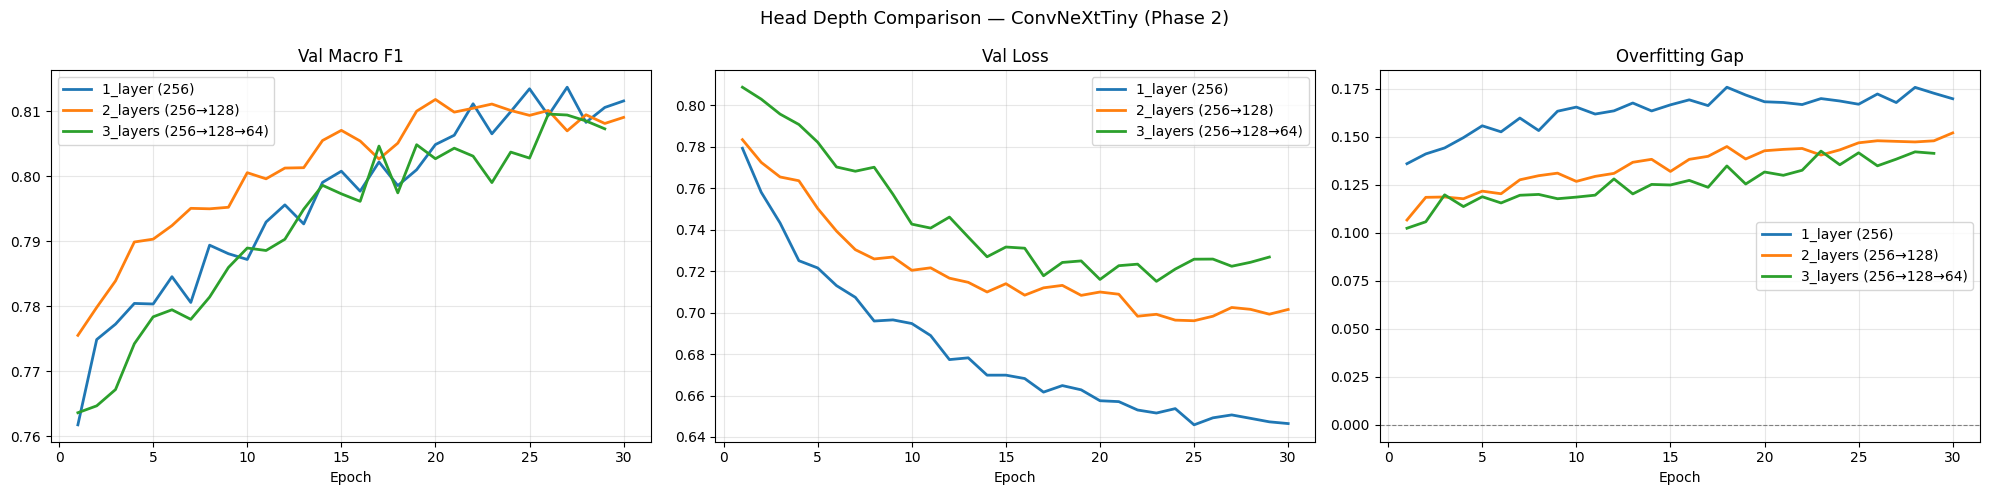

In [ ]:
# Curves (ConvNeXtTiny, Phase 2)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Head Depth Comparison — ConvNeXtTiny (Phase 2)', fontsize=13)

for exp_name, r in head_results_convnext.items():
    hist   = r['p2_history']
    label  = f"{r['head']} ({'→'.join(str(u) for u in r['dense_units'])})"
    epochs = range(1, len(hist['val_macro_f1']) + 1)
    gap    = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]

    axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2)
    axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2)
    axes[2].plot(epochs, gap,                  label=label, linewidth=2)

for ax, title in zip(axes, ['Val Macro F1', 'Val Loss', 'Overfitting Gap']):
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'head_comparison_ConvNeXtTiny.png'), dpi=150)
plt.show()

In [ ]:
# EfficientNetV2S
# Tests head depth (1, 2, 3 Dense layers) on EfficientNetV2S, Phase 1 + Phase 2.

head_results_effnet = {}
backbone_name = 'EfficientNetV2S'
n_unfreeze    = UNFREEZE_CONFIG[backbone_name]
cfg           = BACKBONE_CONFIGS[backbone_name]

for head_name, head_cfg in HEAD_CONFIGS.items():
    exp_name = f"{backbone_name}_head_{head_name}"
    print(f'\n{"="*60}\n  {exp_name}  (unfreeze={n_unfreeze})\n{"="*60}')

    model, backbone = build_base_model(
        backbone_name    = backbone_name,
        backbone_configs = BACKBONE_CONFIGS,
        num_classes      = NUM_CLASSES,
        activation_name  = HEAD_ACTIVATION,
        head_config      = head_cfg,
    )

        # Phase 1 — frozen backbone, head warm-up
    hist_p1, phase1_weights = run_phase1(
        model, backbone, cfg['train_ds'], cfg['val_ds'],
        backbone_name     = exp_name,
        phase1_config     = PHASE1_CONFIG,
        phase2_config     = PHASE2_CONFIG,
        make_metrics      = make_metrics,
        class_weight_dict = class_weight_dict,
    )

    # Phase 2 — unfreeze top layers, fine-tune end-to-end
    hist_p2 = run_phase2(
        model, backbone, cfg['train_ds'], cfg['val_ds'],
        phase1_weights    = phase1_weights,
        backbone_name     = exp_name,
        n_unfreeze        = n_unfreeze,
        phase1_config     = PHASE1_CONFIG,
        phase2_config     = PHASE2_CONFIG,
        make_metrics      = make_metrics,
        class_weight_dict = class_weight_dict,
    )

    head_results_effnet[exp_name] = {
        'backbone':    backbone_name,
        'head':        head_name,
        'dense_units': head_cfg['dense_units'],
        **extract_best_metrics(hist_p1, prefix='p1'),
        **extract_best_metrics(hist_p2, prefix='p2'),
    }

    r = head_results_effnet[exp_name]
    print(f'\n  {exp_name}')
    print(f'  Phase 1 → Val F1 : {r["p1_val_f1"]:.4f}')
    print(f'  Phase 2 → Val F1 : {r["p2_val_f1"]:.4f}')
    print(f'  Phase 2 → Top-3  : {r["p2_val_top3"]:.4f}')
    print(f'  Overfitting gap  : {r["p2_overfit"]:.4f}')

    del model, backbone
    keras.backend.clear_session()
    gc.collect()


  EfficientNetV2S_head_1_layer  (unfreeze=30)
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 218s 486ms/step - loss: 1.9523 - macro_f1: 0.4392 - top3_accuracy: 0.6831 - val_loss: 1.2808 - val_macro_f1: 0.5936 - val_top3_accuracy: 0.8271 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 301ms/step - loss: 1.3699 - macro_f1: 0.5753 - top3_accuracy: 0.8129 - val_loss: 1.1996 - val_macro_f1: 0.6265 - val_top3_accuracy: 0.8506 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 304ms/step - loss: 1.2066 - macro_f1: 0.6149 - top3_accuracy: 0.8383 - val_loss: 1.1100 - val_macro_f1: 0.6552 - val_top3_accuracy: 0.8646 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 301ms/step - loss: 1.1112 - macro_f1: 0.6397 - top3_accuracy: 0.8607 - val_loss: 1.1002 - val_macro_f1: 0.6562 - val_top3_accuracy: 0.8631 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 301ms/step - loss: 1.0445 - m

In [ ]:
# Results table (EfficientNetV2S)
print(f'\nHead comparison for backbone: EfficientNetV2S\n')
print(f'{"Experiment":<40} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 85)

for name, r in sorted(head_results_effnet.items(), key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{name:<40} {r["p2_val_f1"]:>10.4f} {r["p2_val_top3"]:>10.4f} '
          f'{r["p2_val_loss"]:>12.4f} {r["p2_overfit"]:>10.4f}')


Head comparison for backbone: EfficientNetV2S

Experiment                                P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
-------------------------------------------------------------------------------------
EfficientNetV2S_head_1_layer                 0.7554     0.9125       0.7906     0.0823
EfficientNetV2S_head_3_layers                0.7549     0.8956       0.8289     0.0156
EfficientNetV2S_head_2_layers                0.7546     0.9175       0.7640     0.0362


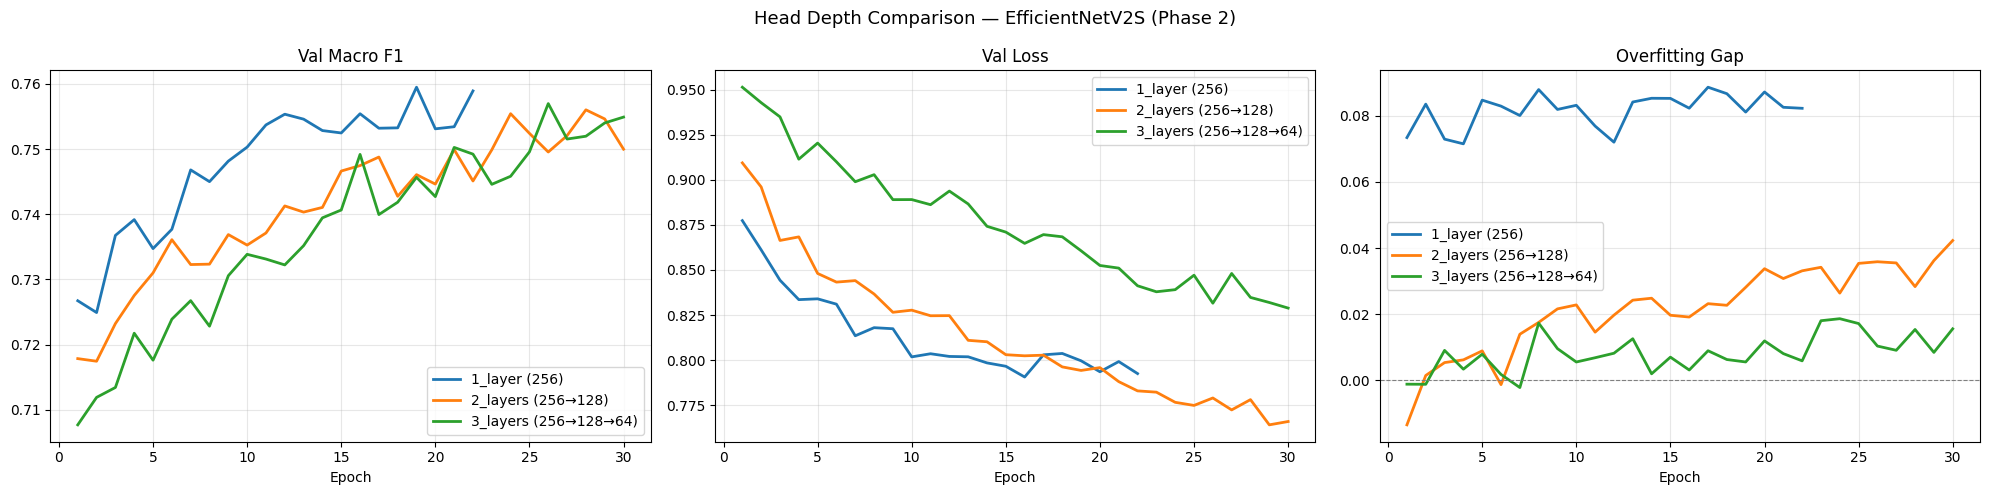

In [ ]:
# Curves(EfficientNetV2S, Phase 2)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Head Depth Comparison — EfficientNetV2S (Phase 2)', fontsize=13)

for exp_name, r in head_results_effnet.items():
    hist   = r['p2_history']
    label  = f"{r['head']} ({'→'.join(str(u) for u in r['dense_units'])})"
    epochs = range(1, len(hist['val_macro_f1']) + 1)
    gap    = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]

    axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2)
    axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2)
    axes[2].plot(epochs, gap,                  label=label, linewidth=2)

for ax, title in zip(axes, ['Val Macro F1', 'Val Loss', 'Overfitting Gap']):
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'head_comparison_EfficientNetV2S.png'), dpi=150)
plt.show()

### <font color='#2f94d7' size=5>**6.4.4 Hyperband Tuning**</font> <a class="anchor" id="6_4_4"></a>

#### <font color='#2f94d7' size=5>**6.4.5.1 EfficientNetV2S**</font> <a class="anchor" id="6_4_5_1"></a>

In [ ]:
hyperband_results = {}

cfg = BACKBONE_CONFIGS['EfficientNetV2S']

best_hp, results = run_hyperband(
    backbone_name='EfficientNetV2S',
    activation_name=HEAD_ACTIVATION,
    train=cfg['train_ds'],
    val=cfg['val_ds'],
    n_unfreeze=30,
    n_dense_layers=2,
    backbone_configs=BACKBONE_CONFIGS,
    phase1_config=PHASE1_CONFIG,
    phase2_config=PHASE2_CONFIG,
    num_classes=NUM_CLASSES,
    class_weight_dict=class_weight_dict,
    make_metrics=make_metrics,
    max_epochs=20,
    factor=3
)

hyperband_results['EfficientNetV2S'] = {'best_hp': best_hp, 'results': results}

keras.backend.clear_session()
gc.collect()

Trial 15 Complete [00h 14m 43s]
val_macro_f1: 0.6900361180305481

Best val_macro_f1 So Far: 0.6900361180305481
Total elapsed time: 02h 00m 16s

Search: Running Trial #16

Value             |Best Value So Far |Hyperparameter
0.4               |0.3               |dropout
0.0002            |0.00015416        |lr_p1
512               |512               |dense_units_1
256               |256               |dense_units_2
7                 |7                 |tuner/epochs
3                 |3                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
1                 |1                 |tuner/round
0000              |0002              |tuner/trial_id

Epoch 4/7


In [ ]:
r = hyperband_results['EfficientNetV2S']['results']
print(f'\nHyperband results for backbone: EfficientNetV2S\n')
print(f'{"Metric":<20} {"Value":>10}')
print('-' * 35)
print(f'{"P1 Val F1":<20} {r["p1_val_f1"]:>10.4f}')
print(f'{"P2 Val F1":<20} {r["p2_val_f1"]:>10.4f}')
print(f'{"P2 Top-3":<20} {r["p2_val_top3"]:>10.4f}')
print(f'{"P2 Val Loss":<20} {r["p2_val_loss"]:>10.4f}')
print(f'{"Overfit Gap":<20} {r["p2_overfit"]:>10.4f}')

hp_info = hyperband_results['EfficientNetV2S']
print(f'\nBest HPs found:')
print(f'  dense_units : {hp_info["dense_units"]}')
print(f'  dropout     : {hp_info["dropout"]}')
print(f'  lr_p1       : {hp_info["lr_p1"]:.6f}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Hyperband Best Model — EfficientNetV2S (Phase 2)', fontsize=13)

for phase, prefix, linestyle in [('Phase 1', 'p1', '--'), ('Phase 2', 'p2', '-')]:
    hist   = r[f'{prefix}_history']
    epochs = range(1, len(hist['val_macro_f1']) + 1)
    gap    = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]
    label  = phase

    axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2, linestyle=linestyle)
    axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2, linestyle=linestyle)
    axes[2].plot(epochs, gap,                  label=label, linewidth=2, linestyle=linestyle)

for ax, title in zip(axes, ['Val Macro F1', 'Val Loss', 'Overfitting Gap']):
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hyperband_EfficientNetV2S.png'), dpi=150)
plt.show()

#### <font color='#2f94d7' size=5>**6.4.2.1 ConvNeXtTiny**</font> <a class="anchor" id="6_4_5_2"></a>

In [ ]:
# Hyperband on ConvNeXtTiny
hyperband_results = {}

cfg = BACKBONE_CONFIGS['ConvNeXtTiny']

best_hp, results = run_hyperband(
    backbone_name='ConvNeXtTiny',
    activation_name=HEAD_ACTIVATION,
    train=cfg['train_ds'],
    val=cfg['val_ds'],
    n_unfreeze=50,
    n_dense_layers=1,
    backbone_configs=BACKBONE_CONFIGS,
    phase1_config=PHASE1_CONFIG,
    phase2_config=PHASE2_CONFIG,
    num_classes=NUM_CLASSES,
    class_weight_dict=class_weight_dict,
    make_metrics=make_metrics,
    max_epochs=20,
    factor=3
)

hyperband_results['ConvNeXtTiny'] = {'best_hp': best_hp, 'results': results}

keras.backend.clear_session()
gc.collect()

Trial 30 Complete [00h 27m 53s]
val_macro_f1: 0.7676326036453247

Best val_macro_f1 So Far: 0.7851963639259338
Total elapsed time: 06h 25m 22s

  Best HPs for ConvNeXtTiny:
  dense_units_1 : 512
  dropout          : 0.30000000000000004
  lr_p1            : 0.002071
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 268ms/step - loss: 1.6184 - macro_f1: 0.5426 - top3_accuracy: 0.7767 - val_loss: 1.1100 - val_macro_f1: 0.6429 - val_top3_accuracy: 0.8671 - learning_rate: 0.0021
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 229ms/step - loss: 0.9465 - macro_f1: 0.7028 - top3_accuracy: 0.8938 - val_loss: 1.0542 - val_macro_f1: 0.6854 - val_top3_accuracy: 0.8821 - learning_rate: 0.0021
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - loss: 0.7518 - macro_f1: 0.7561 - top3_accuracy: 0.9280 - val_loss: 0.9793 - val_macro_f1: 0.7062 - val_top3_accuracy: 0.8951 - learning_rate: 0.0021
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 215ms/step - loss: 0.6376 - macro_f1: 0.7861 - top3_accuracy: 0.9419 -

0

In [ ]:
r = hyperband_results['ConvNeXtTiny']['results']
print(f'\nHyperband results for backbone: ConvNeXtTiny\n')
print(f'{"Metric":<20} {"Value":>10}')
print('-' * 35)
print(f'{"P1 Val F1":<20} {r["p1_val_f1"]:>10.4f}')
print(f'{"P2 Val F1":<20} {r["p2_val_f1"]:>10.4f}')
print(f'{"P2 Top-3":<20} {r["p2_val_top3"]:>10.4f}')
print(f'{"P2 Val Loss":<20} {r["p2_val_loss"]:>10.4f}')
print(f'{"Overfit Gap":<20} {r["p2_overfit"]:>10.4f}')

hp_info = hyperband_results['ConvNeXtTiny']
best_hp = hp_info['best_hp']
print(f'\nBest HPs found:')
#print(f'  dense_units : {best_hp.get(["dense_units_2"])}')
print(f'  dense_units_1 : {best_hp.get(f"dense_units_1")}')

print(f'  dropout     : {best_hp.get(f"dropout")}')
print(f'  lr_p1       : {best_hp.get(f"lr_p1")}')


Hyperband results for backbone: ConvNeXtTiny

Metric                    Value
-----------------------------------
P1 Val F1                0.7816
P2 Val F1                0.8396
P2 Top-3                 0.9570
P2 Val Loss              0.7133
Overfit Gap              0.1587

Best HPs found:
  dense_units_1 : 512
  dropout     : 0.30000000000000004
  lr_p1       : 0.002070896359590621


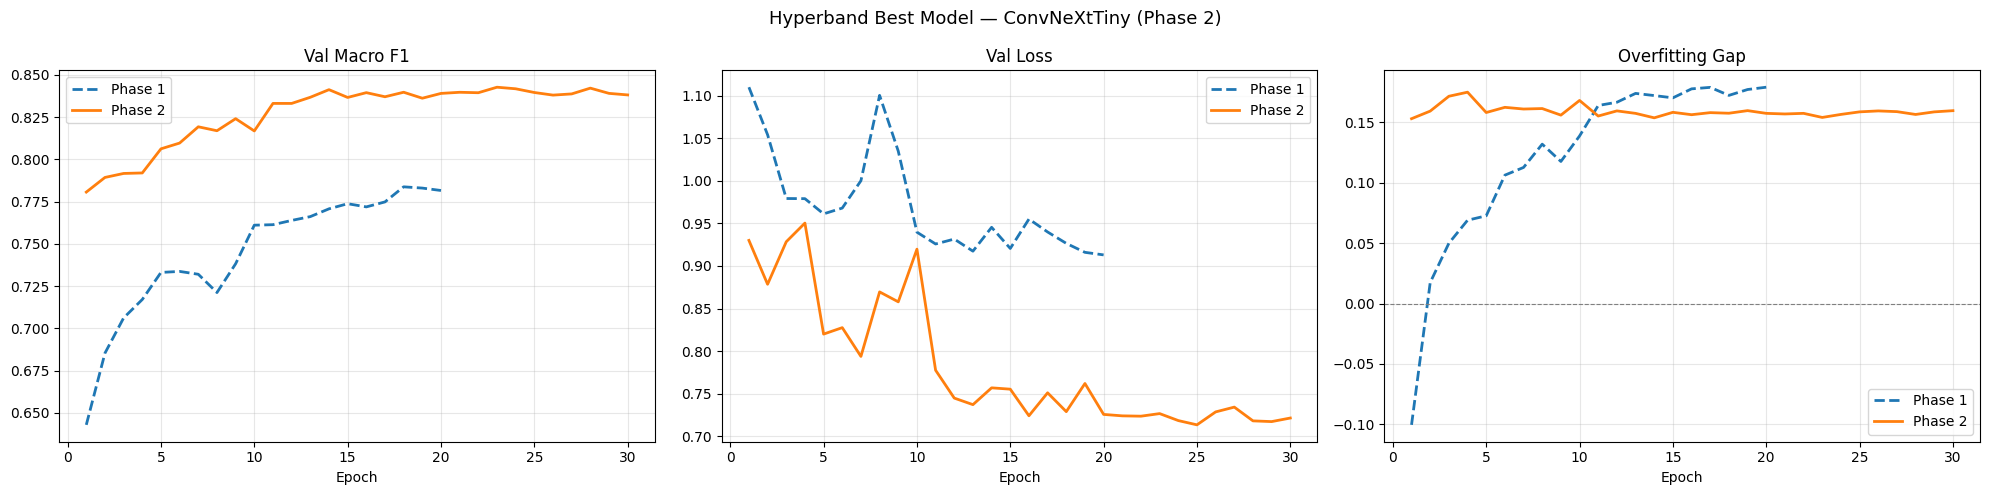

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Hyperband Best Model — ConvNeXtTiny (Phase 2)', fontsize=13)

for phase, prefix, linestyle in [('Phase 1', 'p1', '--'), ('Phase 2', 'p2', '-')]:
    hist   = r[f'{prefix}_history']
    epochs = range(1, len(hist['val_macro_f1']) + 1)
    gap    = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]
    label  = phase

    axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2, linestyle=linestyle)
    axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2, linestyle=linestyle)
    axes[2].plot(epochs, gap,                  label=label, linewidth=2, linestyle=linestyle)

for ax, title in zip(axes, ['Val Macro F1', 'Val Loss', 'Overfitting Gap']):
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hyperband_ConvNeXtTiny.png'), dpi=150)
plt.show()

# <font color='#2f94d7' size=5>**7 Final Model**</font> <a class="anchor" id="7"></a>

In [ ]:
# Define the best hyperparameters found by Hyperband for each backbone (to be used in final training + test evaluation)

BEST_BACKBONE    = 'ConvNeXtTiny'
BEST_DENSE_UNITS = [256]        # SUBSTITUIR
BEST_DROPOUT = 0.3          # SUBSTITUIR
BEST_LR_P1       = 1e-3        # SUBSTITUIR
BEST_EPOCHS_P1   = 20          
BEST_EPOCHS_P2   = 30        
N_UNFREEZE = 50

# Concatenate train + val for final training (test will be used as "val" just for preprocessing, not for training)
trainval_raw = train_ds_raw.concatenate(val_ds_raw)


# ── ConvNeXtTiny — trainval + test ────────────────────────────────────────────
trainval_final, test_final = apply_augmented_preprocess_ds(
    train_raw=trainval_raw,
    val_raw=test_ds_raw,
    preprocess_fn=BACKBONE_CONFIGS['ConvNeXtTiny']['preprocess'],
    augmentation_model=AUGMENTATION_CONFIGS['grayscale_mix_final'],
    AUTOTUNE=AUTOTUNE,
    batch_size=BATCH_SIZE,
    image_size=224
)

In [ ]:
# Train final model
final_model, final_bb = build_base_model(
    backbone_name=BEST_BACKBONE,
    backbone_configs=BACKBONE_CONFIGS,
    num_classes=NUM_CLASSES,
    activation_name=HEAD_ACTIVATION,
    head_config={
        'dense_units':  BEST_DENSE_UNITS,
        'dropout_rate': BEST_DROPOUT
    }
)

# Phase 1
final_bb.trainable = False
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR_P1),
    loss='sparse_categorical_crossentropy',
    metrics=make_metrics(num_classes=NUM_CLASSES)
)

final_model.fit(
    trainval_final,
    epochs=BEST_EPOCHS_P1,
    class_weight=class_weight_dict,
    verbose=1
)

phase1_weights_effnet = final_model.get_weights()

# Phase 2
final_bb.trainable = True
for layer in final_bb.layers[:-N_UNFREEZE]:
    layer.trainable = False

final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR_P1 / 10),
    loss='sparse_categorical_crossentropy',
    metrics=make_metrics(num_classes=NUM_CLASSES)
)
final_model.set_weights(phase1_weights_effnet)
final_model.fit(
    trainval_final,
    epochs=BEST_EPOCHS_P2,
    class_weight=class_weight_dict,
    verbose=1
)

# Save the model
final_model.save("final_model_convnext.keras")

In [ ]:
# Load best fine-tuned weights for final evaluation
model = load_model("final_model.keras", compile=False)

test_loss, test_macro_f1, test_top3 = model.evaluate(test_final, verbose=1)
print(f'\nTest  Loss     : {test_loss:.4f}')
print(f'Test  Macro F1 : {test_macro_f1:.4f}  ({test_macro_f1*100:.2f}%)')
print(f'Test  Top-3 Acc: {test_top3:.4f}  ({test_top3*100:.2f}%)')

In [ ]:
# Predictions
y_pred_probs = final_model.predict(test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for _, y in test_final], axis=0)

# Classification report 
print("\nClassification Report:\n")

report = classification_report(y_true, y_pred, target_names=class_names, digits=3)

print(report)

In [ ]:
# Top-3 Accuracy
top3 = np.mean([
    y_true[i] in np.argsort(y_pred_probs[i])[-3:]
    for i in range(len(y_true))
])

print(f"Top-3 Accuracy: {top3:.4f} ({top3*100:.2f}%)")

In [ ]:
# Classification report in dictionary format
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Extract F1 scores and class names
f1_scores = [report[name]['f1-score'] for name in class_names]

# Order
sorted_idx = np.argsort(f1_scores)

sorted_names = np.array(class_names)[sorted_idx]
sorted_f1 = np.array(f1_scores)[sorted_idx]

plt.figure(figsize=(12, 6))
plt.bar(sorted_names, sorted_f1)

plt.xticks(rotation=90)
plt.ylabel("F1-score")
plt.title("F1-score per Class (sorted)")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # per-row normalisation

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Predicted Artist', fontsize=12)
ax.set_ylabel('True Artist', fontsize=12)
ax.set_title('Normalised Confusion Matrix (row = true class)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# <font color='#2f94d7' size=5>**8 Error Analysis**</font> <a class="anchor" id="8"></a>

In [ ]:
# Extract images from dataset
images = np.concatenate([x for x, y in test_final], axis=0)

# Mask of wrong predictions
wrong_mask = y_pred != y_true

wrong_images = images[wrong_mask]
wrong_true   = y_true[wrong_mask]
wrong_pred   = y_pred[wrong_mask]
wrong_probs  = y_pred_probs[wrong_mask]
wrong_conf   = np.max(wrong_probs, axis=1)

# Top 12 highest-confidence mistakes
high_conf_idx = np.argsort(wrong_conf)[::-1][:12]

# Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, idx in zip(axes.flatten(), high_conf_idx):
    ax.imshow(wrong_images[idx].astype("uint8"))
    ax.axis("off")

    true_name = class_names[wrong_true[idx]].replace('_', ' ')
    pred_name = class_names[wrong_pred[idx]].replace('_', ' ')

    conf = wrong_conf[idx]

    ax.set_title(
        f"True: {true_name}\nPred: {pred_name} ({conf:.2f})",
        fontsize=8,
        color='red'
    )

plt.suptitle("High-Confidence Misclassifications", fontsize=14)
plt.tight_layout()
plt.show()